In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('canada_immigration.csv')
df.columns = df.columns.astype(str)
df.head()

,Unnamed: 0,Draw Number,Date,Immigration program,Invitations issued,CRS score of lowest-ranked candidate invited,Date (hidden),Programs covered,Month,Year,month_year,Date Full
0,0,172,1/7/2021,Canadian Experience Class,4750,461,7/1/2021,Canadian Experience Class,1,2021,1/1/2021,7-Jan-21
1,1,171,1/6/2021,Provincial Nominee Program,250,813,6/1/2021,Provincial Nominee Program,1,2021,1/1/2021,6-Jan-21
2,2,170,12/23/2020,No program specified,5000,468,12/23/2020,Canadian Experience Class Federal Skilled Wor...,12,2020,12/1/2020,23-Dec-20
3,3,169,12/9/2020,No program specified,5000,469,9/12/2020,Canadian Experience Class Federal Skilled Wor...,12,2020,12/1/2020,9-Dec-20
4,4,168,11/25/2020,No program specified,5000,469,11/25/2020,Canadian Experience Class Federal Skilled Wor...,11,2020,11/1/2020,25-Nov-20


In [23]:
# standardize key columns when dataset schema differs
if 'Country' not in df.columns:
    if 'Immigration program' in df.columns:
        df = df.rename(columns={'Immigration program': 'Country'})
    elif 'Programs covered' in df.columns:
        df = df.rename(columns={'Programs covered': 'Country'})

# detect year columns
years = [col for col in df.columns if col.isdigit()]

# if data is long format, aggregate into wide format
if len(years) == 0 and 'Year' in df.columns:
    # choose a numeric immigration count column for pivot values
    value_col = None
    for candidate in ['Invitations issued', 'Total', 'Value', 'Count']:
        if candidate in df.columns:
            value_col = candidate
            break

    if value_col is None:
        numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
        value_col = numeric_cols[0] if numeric_cols else None

    if value_col is None or 'Country' not in df.columns:
        raise ValueError("Could not infer required columns. Need country/program, year, and numeric value columns.")

    df = (
        df.groupby(['Country', 'Year'], as_index=False)[value_col]
        .sum()
        .pivot(index='Country', columns='Year', values=value_col)
        .fillna(0)
        .reset_index()
    )
    df.columns = df.columns.astype(str)
    years = [col for col in df.columns if col.isdigit()]

# keep years in chronological order
years = sorted(years, key=int)

df['Total'] = df[years].sum(axis=1)
df.head()

Year,Country,2015,2016,2017,2018,2019,2020,2021,Total
0,Canadian Experience Class,849.0,0.0,0.0,0.0,0.0,34215.0,4750.0,39814.0
1,Federal Skilled Trades,0.0,0.0,905.0,900.0,1000.0,250.0,0.0,3055.0
2,No program specified,30214.0,33223.0,84685.0,88700.0,84300.0,68100.0,0.0,389222.0
3,Provincial Nominee Program,0.0,559.0,433.0,200.0,0.0,4785.0,250.0,6227.0


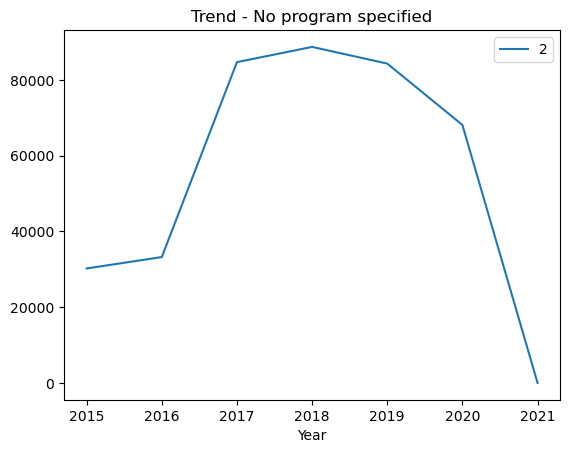

In [24]:
# trend for one country/program
country = 'India'
if country not in df['Country'].values:
    country = df.sort_values('Total', ascending=False).iloc[0]['Country']

data = df[df['Country'] == country][years].T

data.plot()
plt.title(f'Trend - {country}')
plt.show()

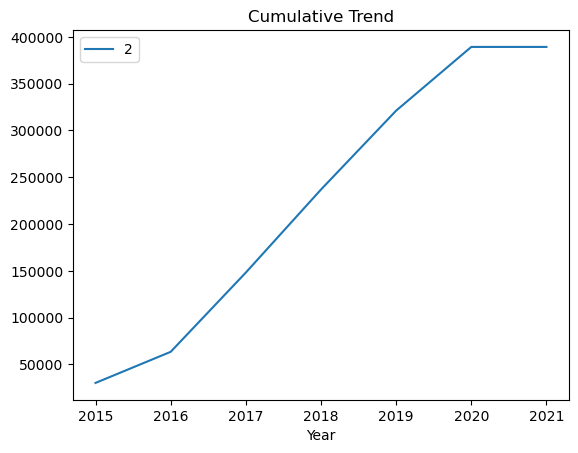

In [25]:
# cumulative trend
data.cumsum().plot()
plt.title('Cumulative Trend')
plt.show()

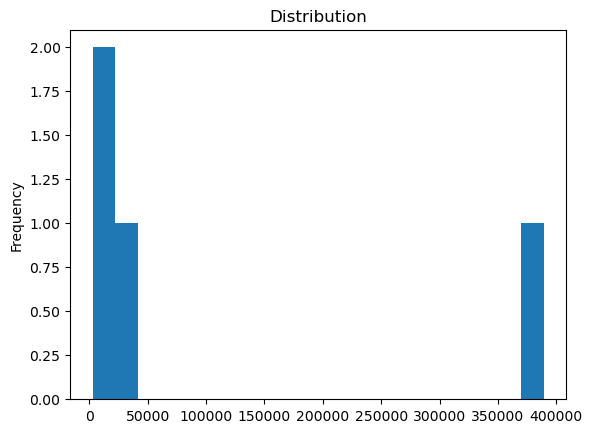

In [26]:
# distribution
df['Total'].plot(kind='hist', bins=20)
plt.title('Distribution')
plt.show()

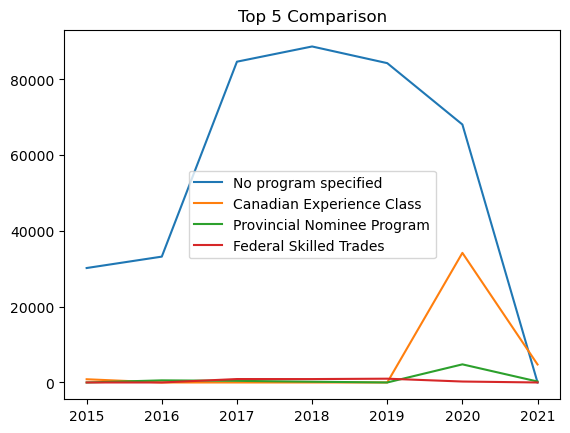

In [27]:
# top 5 countries comparison
top5 = df.sort_values(by='Total', ascending=False).head(5)

for i in range(len(top5)):
    plt.plot(years, top5.iloc[i][years], label=top5.iloc[i]['Country'])

plt.legend()
plt.title('Top 5 Comparison')
plt.show()

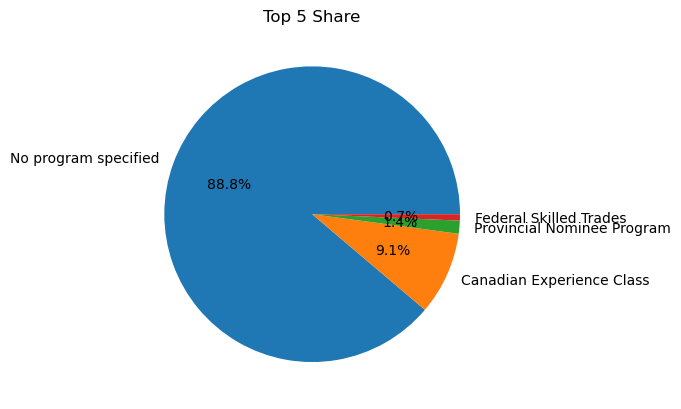

In [28]:
# pie chart
top5.set_index('Country')['Total'].plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5 Share')
plt.ylabel('')
plt.show()

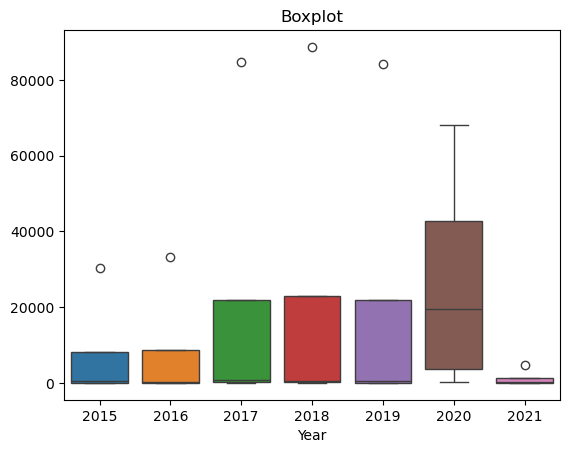

In [29]:
# boxplot
sns.boxplot(data=df[years])
plt.title('Boxplot')
plt.show()

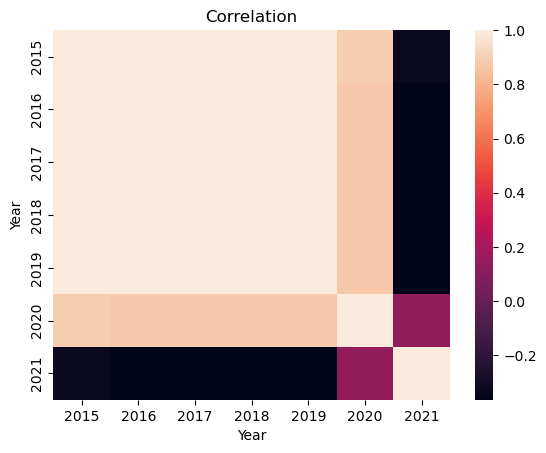

In [30]:
# heatmap
sns.heatmap(df[years].corr())
plt.title('Correlation')
plt.show()

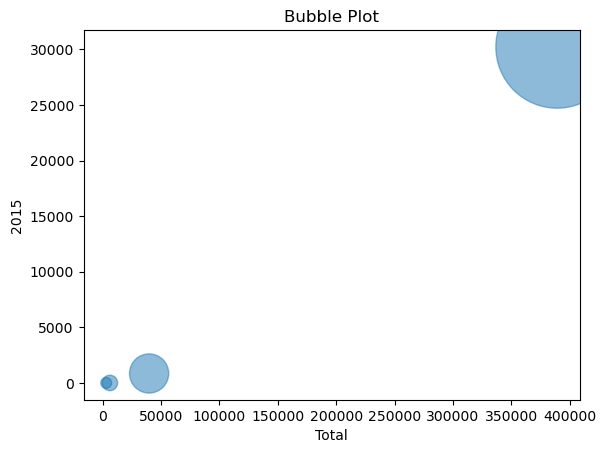

In [31]:
# bubble plot
plt.scatter(df['Total'], df[years[0]], s=df['Total']/50, alpha=0.5)
plt.xlabel('Total')
plt.ylabel(years[0])
plt.title('Bubble Plot')
plt.show()

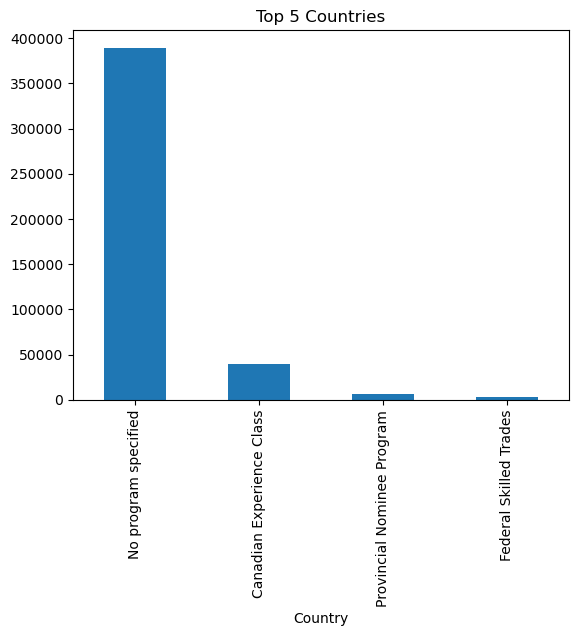

In [32]:
# bar chart
top5.set_index('Country')['Total'].plot(kind='bar')
plt.title('Top 5 Countries')
plt.show()

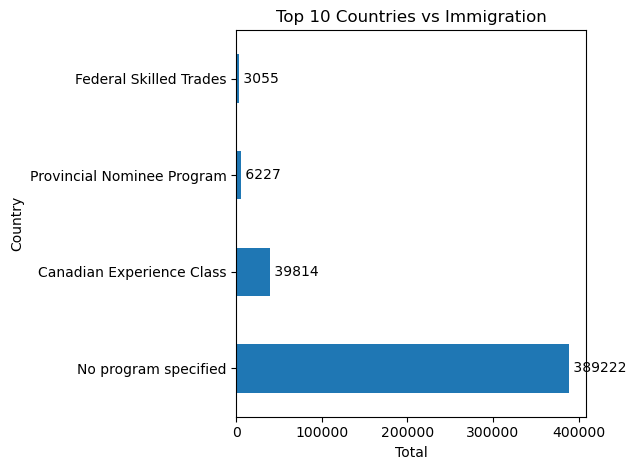

In [33]:
# annotated top-10 chart (safer than free text canvas placement)
top10 = df.sort_values(by='Total', ascending=False).head(10)

ax = top10.plot(kind='barh', x='Country', y='Total', legend=False)
for i, v in enumerate(top10['Total']):
    ax.text(v, i, f' {int(v)}', va='center')

plt.title('Top 10 Countries vs Immigration')
plt.xlabel('Total')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

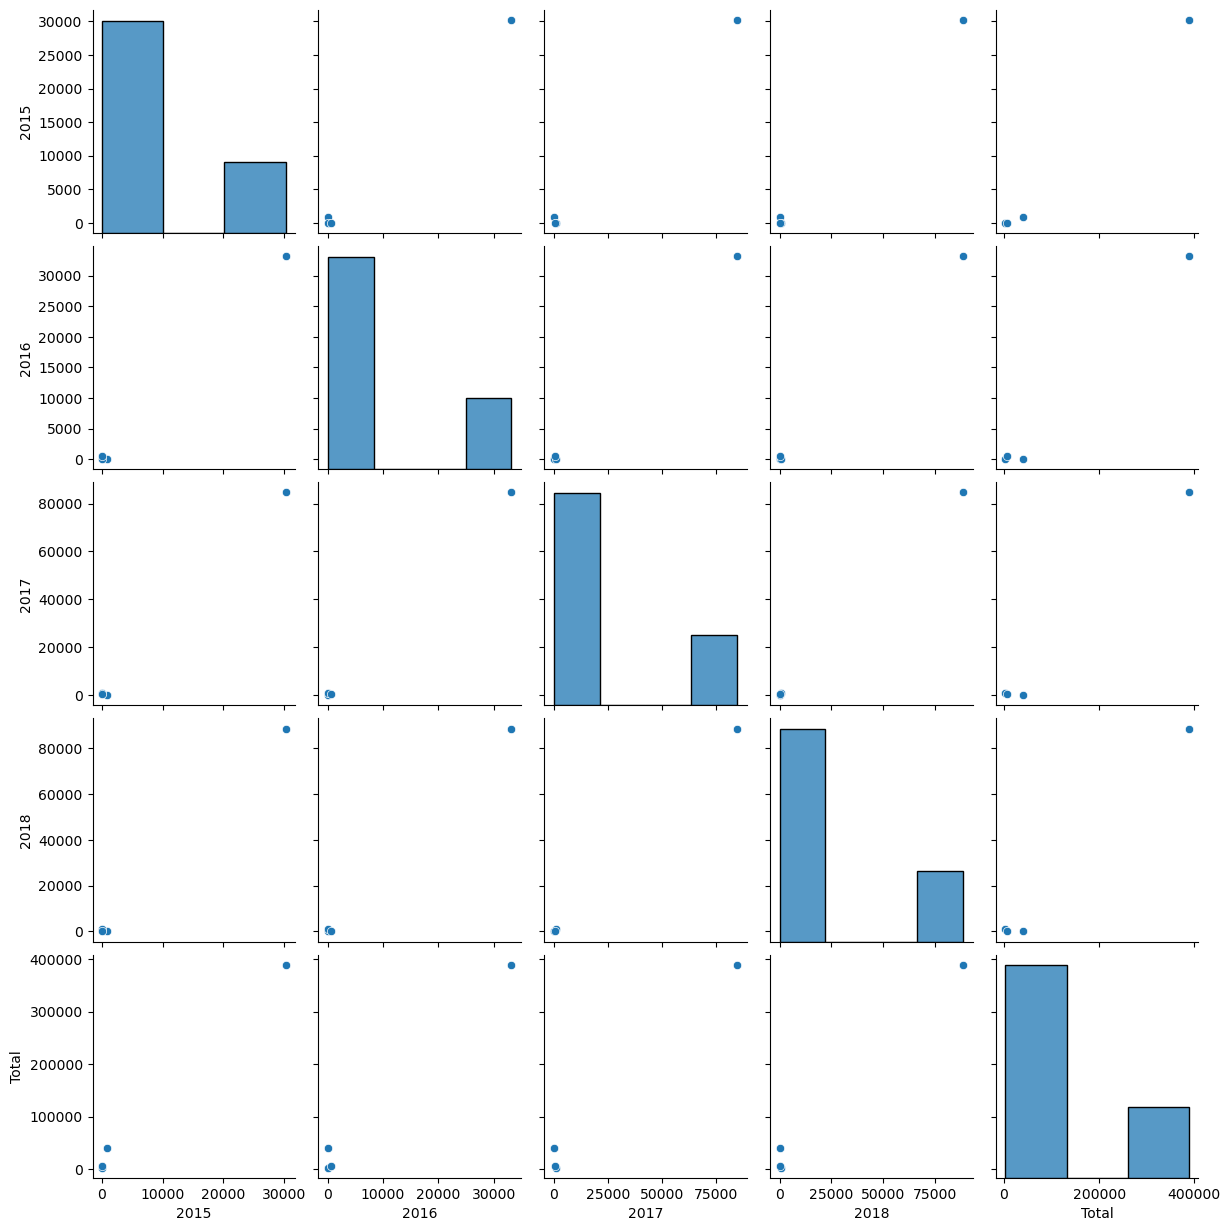

In [34]:
# seaborn pairplot
sample = df[years[:4] + ['Total']]
sns.pairplot(sample)
plt.show()